In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rc
import os

import bilby

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import icarogw
import healpy as hp
from  astropy.cosmology import FlatLambdaCDM
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

# Your custom text color
mycolor = 'black'  # or e.g., '#fe9463', (0.996, 0.580, 0.388)
from matplotlib import rcParams
# Global style settings
rcParams.update({
    # Enable LaTeX rendering
    'text.usetex': True,

    # Font settings
    'font.family': 'sans-serif',
    'font.sans-serif': ['Open Sans'],  # Use Open Sans if available

    # Set all text and visual elements to use the custom color
    'text.color': mycolor,
    'axes.labelcolor': mycolor,
    'xtick.color': mycolor,
    'ytick.color': mycolor,
    'axes.edgecolor': mycolor,
    'grid.color': mycolor,
    'legend.edgecolor': mycolor,
    'legend.facecolor': 'none',
    'legend.labelcolor': mycolor,

    # Transparent backgrounds
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
})

if mycolor=='white':
    rcParams['savefig.transparent'] = True

import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor']   = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
# fix tick labels size
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16

Config not imported, automatically decides between Numpy and Cupy
Error in importing cupy


/Users/ulyana.dupletsa/miniconda3/envs/icaro_gwfish/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ska_color_pink = '#d60068'
ska_color_intermediate = '#840068'
ska_color_purple = '#180068'
radio_color = '#f5e15f'

In [3]:
H0_value = 67.7
# Reference cosmology
cosmo_ref = icarogw.cosmology.astropycosmology(zmax=20.)
cosmo_ref.build_cosmology(FlatLambdaCDM(H0=H0_value,Om0=0.308)) 

In [5]:
ref_data = bilby.result.read_in_result('../../results/cosmoPEs_snr150_rs1_nside16_HIHI/label_result.json')

In [6]:
nside = 64 # to recalculate sky localization
npix = hp.nside2npix(nside)

In [7]:
# open samples file
import pickle
with open('../../gw_data/gwfish_results_resampled/samples_from_gwfish_1e4events_SNR150_rs1_nside16_HI.pkl', 'rb') as f:
    samples_tmvn = pickle.load(f)

In [8]:
# get ra and dec samples and transform into probability map
sky_loc = []
luminosity_distance = []
for key in samples_tmvn:
    nside = 64 # to recalculate sky localization
    npix = hp.nside2npix(nside)
    prob_map = np.zeros(npix)
    ra  = samples_tmvn[key][4,:]
    dec = samples_tmvn[key][5,:]
    dL = np.median(samples_tmvn[key][2,:])

    theta = np.pi/2. - dec
    phi   = ra
    
    pix = hp.ang2pix(nside, theta, phi)
    # Count samples per pixel
    bincount = np.bincount(pix, minlength=npix)
    prob_map += bincount

    prob_map = prob_map / np.sum(prob_map)
    pix_area = hp.nside2pixarea(nside)  # in steradians
    prob_density = prob_map / pix_area

    # Sort pixels by probability descending
    sorted_idx = np.argsort(prob_map)[::-1]
    sorted_prob = prob_map[sorted_idx]

    cumulative = np.cumsum(sorted_prob)

    # Find pixels inside 90%
    n90 = np.searchsorted(cumulative, 0.9)

    area_90_sr = n90 * pix_area
    area_90_deg2 = area_90_sr * (180/np.pi)**2

    if area_90_deg2 < 10:
        nside = 254 # to recalculate sky localization
        pix = hp.ang2pix(nside, theta, phi)
        npix = hp.nside2npix(nside)
        prob_map = np.zeros(npix)
        # Count samples per pixel
        bincount = np.bincount(pix, minlength=npix)
        prob_map += bincount

        prob_map = prob_map / np.sum(prob_map)
        pix_area = hp.nside2pixarea(nside)  # in steradians
        prob_density = prob_map / pix_area

        # Sort pixels by probability descending
        sorted_idx = np.argsort(prob_map)[::-1]
        sorted_prob = prob_map[sorted_idx]

        cumulative = np.cumsum(sorted_prob)

        # Find pixels inside 90%
        n90 = np.searchsorted(cumulative, 0.9)

        area_90_sr = n90 * pix_area
        area_90_deg2 = area_90_sr * (180/np.pi)**2

        if area_90_deg2 < 1:
            nside = 512 # to recalculate sky localization
            pix = hp.ang2pix(nside, theta, phi)
            npix = hp.nside2npix(nside)
            prob_map = np.zeros(npix)
            # Count samples per pixel
            bincount = np.bincount(pix, minlength=npix)
            prob_map += bincount

            prob_map = prob_map / np.sum(prob_map)
            pix_area = hp.nside2pixarea(nside)  # in steradians
            prob_density = prob_map / pix_area

            # Sort pixels by probability descending
            sorted_idx = np.argsort(prob_map)[::-1]
            sorted_prob = prob_map[sorted_idx]

            cumulative = np.cumsum(sorted_prob)

            # Find pixels inside 90%
            n90 = np.searchsorted(cumulative, 0.9)

            area_90_sr = n90 * pix_area
            area_90_deg2 = area_90_sr * (180/np.pi)**2

            if area_90_deg2 < 0.05:
                nside = 1024 # to recalculate sky localization
                pix = hp.ang2pix(nside, theta, phi)
                npix = hp.nside2npix(nside)
                prob_map = np.zeros(npix)
                # Count samples per pixel
                bincount = np.bincount(pix, minlength=npix)
                prob_map += bincount

                prob_map = prob_map / np.sum(prob_map)
                pix_area = hp.nside2pixarea(nside)  # in steradians
                prob_density = prob_map / pix_area

                # Sort pixels by probability descending
                sorted_idx = np.argsort(prob_map)[::-1]
                sorted_prob = prob_map[sorted_idx]

                cumulative = np.cumsum(sorted_prob)

                # Find pixels inside 90%
                n90 = np.searchsorted(cumulative, 0.9)

                area_90_sr = n90 * pix_area
                area_90_deg2 = area_90_sr * (180/np.pi)**2

                if area_90_deg2 < 0.005:
                    nside = 2048 # to recalculate sky localization
                    pix = hp.ang2pix(nside, theta, phi)
                    npix = hp.nside2npix(nside)
                    prob_map = np.zeros(npix)
                    # Count samples per pixel
                    bincount = np.bincount(pix, minlength=npix)
                    prob_map += bincount

                    prob_map = prob_map / np.sum(prob_map)
                    pix_area = hp.nside2pixarea(nside)  # in steradians
                    prob_density = prob_map / pix_area

                    # Sort pixels by probability descending
                    sorted_idx = np.argsort(prob_map)[::-1]
                    sorted_prob = prob_map[sorted_idx]

                    cumulative = np.cumsum(sorted_prob)

                    # Find pixels inside 90%
                    n90 = np.searchsorted(cumulative, 0.9)

                    area_90_sr = n90 * pix_area
                    area_90_deg2 = area_90_sr * (180/np.pi)**2

    sky_loc.append(area_90_deg2)
    luminosity_distance.append(dL)

sky_dL_values = {
    'sky_loc':sky_loc,
    'dL':luminosity_distance
}

In [9]:
nside = 16
npix = hp.nside2npix(nside)
whole_sky = 4*np.pi*(180./np.pi)**2
pixel_area = whole_sky/npix
pixel_area

13.42869832337867

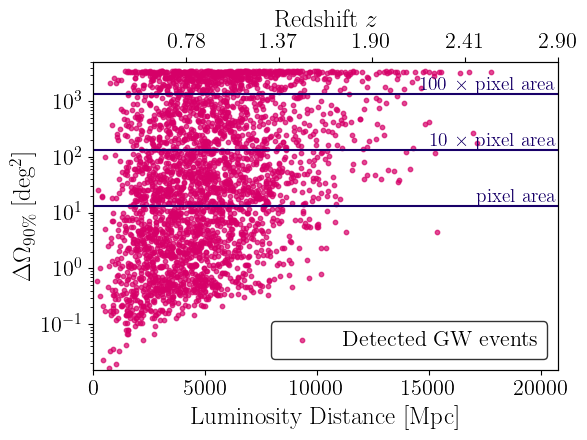

In [10]:
# compare observed events distribution vs the injections
fig, ax = plt.subplots(figsize=(6,4))

plt.scatter(sky_dL_values['dL'], sky_dL_values['sky_loc'], s=10, color=ska_color_pink, 
            alpha=0.7, rasterized=True, label=r'\rm Detected GW events')
plt.xlabel(r'\rm Luminosity Distance [Mpc]', fontsize=18)
plt.ylabel(r'\rm $\Delta \Omega_{90\%}$ [deg$^2$]', fontsize=18)

plt.yscale('log')
plt.axhline(pixel_area, color = ska_color_purple, linewidth=1.5)
plt.text(18890, 1.15*pixel_area, r"\rm pixel area", 
         horizontalalignment='center', color = ska_color_purple, fontsize=14)
plt.axhline(10*pixel_area, color = ska_color_purple, linewidth=1.5)
plt.text(17850, 1.15*10*pixel_area, r"\rm 10 $\times$ pixel area", 
         horizontalalignment='center', color = ska_color_purple, fontsize=14)
plt.axhline(100*pixel_area, color = ska_color_purple, linewidth=1.5)
plt.text(17650, 1.15*100*pixel_area, r"\rm 100 $\times$ pixel area", 
         horizontalalignment='center', color = ska_color_purple, fontsize=14)

# plot a mirror x axis with redshift
plt.xlim(0, 20750)
ax_top = ax.twiny()
# Match limits
ax_top.set_xlim(ax.get_xlim())
# Choose distance ticks (same as bottom axis)
d_ticks = ax.get_xticks()
# Convert distance → redshift
z_ticks = [
    cosmo_ref.dl2z(d)
    for d in d_ticks if d > 0
]
# Remove invalid (negative) ticks
valid = d_ticks > 0
ax_top.set_xticks(d_ticks[valid])
ax_top.set_xticklabels([f"\\rm {z:.2f}" for z in z_ticks])
ax_top.set_xlabel(r'\rm Redshift $z$', fontsize=18)

ax.legend(loc='lower right', frameon=True, fontsize=16)
plt.ylim(0.015, 5000)
plt.savefig('events_sky_loc_distance_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()